# 👁️ Eye Disease Classification — Pipeline Completo
**Kaggle:** gunavenkatdoddi/eye-diseases-classification

Pipeline de Data & Pipeline Engineer con 4 secciones:
1. **EDA Riguroso** — distribución, calidad, estadísticas por canal
2. **Detección de Duplicados y Leakage** — pHash + Union-Find
3. **Pipeline Reproducible** — split estratificado por pseudo-paciente + manifest SHA-256
4. **Detección de Sesgo de Fuente** — χ², KS-test, Bhattacharyya

> Ejecutar las secciones **en orden**. Cada una consume los outputs de la anterior.

## 🔧 0 · Setup e Instalación

In [1]:
%%capture
!pip install opencv-python-headless scikit-learn scipy albumentations tqdm kaggle

In [2]:
import os, json, hashlib, warnings, logging
from pathlib import Path
from collections import defaultdict
from typing import Optional, List

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedGroupKFold
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

print("✓ Imports OK")

✓ Imports OK


In [6]:

import os
os.environ["KAGGLE_USERNAME"] = "juanrizo"
os.environ["KAGGLE_KEY"]      = "KGAT_464c0c8b25f205fbdcce648f6ab3f131"

!kaggle datasets download -d gunavenkatdoddi/eye-diseases-classification

!unzip eye-diseases-classification.zip -d ./dataset

Dataset URL: https://www.kaggle.com/datasets/gunavenkatdoddi/eye-diseases-classification
License(s): ODbL-1.0
100% 736M/736M [00:09<00:00, 78.9MB/s]

Archive:  eye-diseases-classification.zip
  inflating: ./dataset/dataset/cataract/0_left.jpg  
  inflating: ./dataset/dataset/cataract/103_left.jpg  
  inflating: ./dataset/dataset/cataract/1062_right.jpg  
  inflating: ./dataset/dataset/cataract/1083_left.jpg  
  inflating: ./dataset/dataset/cataract/1084_right.jpg  
  inflating: ./dataset/dataset/cataract/1102_left.jpg  
  inflating: ./dataset/dataset/cataract/1102_right.jpg  
  inflating: ./dataset/dataset/cataract/1115_left.jpg  
  inflating: ./dataset/dataset/cataract/1126_right.jpg  
  inflating: ./dataset/dataset/cataract/112_right.jpg  
  inflating: ./dataset/dataset/cataract/1144_left.jpg  
  inflating: ./dataset/dataset/cataract/1144_right.jpg  
  inflating: ./dataset/dataset/cataract/1164_left.jpg  
  inflating: ./dataset/dataset/cataract/1167_right.jpg  
  inflating: ./dataset

In [7]:
# ── Config global ─────────────────────────────────────────────────────────────
DATA_DIR   = Path("./dataset")   # ajusta si tu estructura es diferente
OUTPUT_DIR = Path("./results")
OUTPUT_DIR.mkdir(exist_ok=True)

CLASSES = ["cataract", "diabetic_retinopathy", "glaucoma", "normal"]
LABEL_MAP = {c: i for i, c in enumerate(CLASSES)}
SPLITS  = ["train", "test"]
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".tif"}

CLASS_PALETTE = {
    "cataract":             "#E63946",
    "diabetic_retinopathy": "#457B9D",
    "glaucoma":             "#2A9D8F",
    "normal":               "#E9C46A",
}

# Detecta estructura automáticamente
if not any((DATA_DIR / s).exists() for s in SPLITS):
    sub = [p for p in DATA_DIR.iterdir() if p.is_dir()]
    if sub:
        DATA_DIR = sub[0]
        print(f"Usando subdirectorio: {DATA_DIR}")

all_imgs = [p for p in DATA_DIR.rglob("*") if p.suffix.lower() in IMG_EXT]
print(f"✓ {len(all_imgs)} imágenes encontradas en {DATA_DIR}")

Usando subdirectorio: dataset/dataset
✓ 4217 imágenes encontradas en dataset/dataset


---
##  2 · EDA Riguroso

Métricas por imagen: blur (Laplacian), brillo, contraste RMS, saturación HSV, estadísticas RGB por canal.

### 2.1 · Extracción de features

In [8]:
BLUR_THRESHOLD     = 100.0
BRIGHTNESS_LOW     = 40.0
BRIGHTNESS_HIGH    = 215.0
CONTRAST_THRESHOLD = 30.0

def extract_features(img_path: Path) -> dict:
    rec = {
        "path": str(img_path), "filename": img_path.name,
        "class": img_path.parent.name, "readable": False,
        "split": next((s for s in SPLITS
                       if f"/{s}/" in str(img_path) or f"\\{s}\\" in str(img_path)), "unknown"),
    }
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        return rec
    rec["readable"] = True
    h, w = img_bgr.shape[:2]
    rec.update({"height": h, "width": w,
                "aspect_ratio": round(w/h, 4), "n_pixels": h*w})

    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    img_hsv  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    rec["blur_laplacian"]  = float(cv2.Laplacian(img_gray, cv2.CV_64F).var())
    rec["is_blurry"]       = rec["blur_laplacian"] < BLUR_THRESHOLD
    rec["brightness_mean"] = float(img_gray.mean())
    rec["is_dark"]         = rec["brightness_mean"] < BRIGHTNESS_LOW
    rec["is_overexposed"]  = rec["brightness_mean"] > BRIGHTNESS_HIGH
    rec["contrast_rms"]    = float(img_gray.std())
    rec["is_low_contrast"] = rec["contrast_rms"] < CONTRAST_THRESHOLD
    rec["saturation_mean"] = float(img_hsv[:,:,1].mean())
    rec["saturation_std"]  = float(img_hsv[:,:,1].std())

    for i, ch in enumerate(["r","g","b"]):
        ch_arr = img_rgb[:,:,i].astype(np.float32)
        rec[f"{ch}_mean"] = float(ch_arr.mean())
        rec[f"{ch}_std"]  = float(ch_arr.std())
        rec[f"{ch}_p5"]   = float(np.percentile(ch_arr, 5))
        rec[f"{ch}_p95"]  = float(np.percentile(ch_arr, 95))

    rec["quality_flag"] = any([rec["is_blurry"], rec["is_dark"],
                                rec["is_overexposed"], rec["is_low_contrast"]])
    return rec

eda_df = pd.DataFrame([extract_features(p) for p in tqdm(all_imgs, desc="EDA scan")])
eda_df.to_csv(OUTPUT_DIR / "image_features.csv", index=False)
readable = eda_df[eda_df["readable"]]
print(f"\n✓ {len(readable)} imágenes leídas | {len(eda_df)-len(readable)} corruptas")

EDA scan:   0%|          | 0/4217 [00:00<?, ?it/s]


✓ 4217 imágenes leídas | 0 corruptas


### 2.2 · Distribución de clases

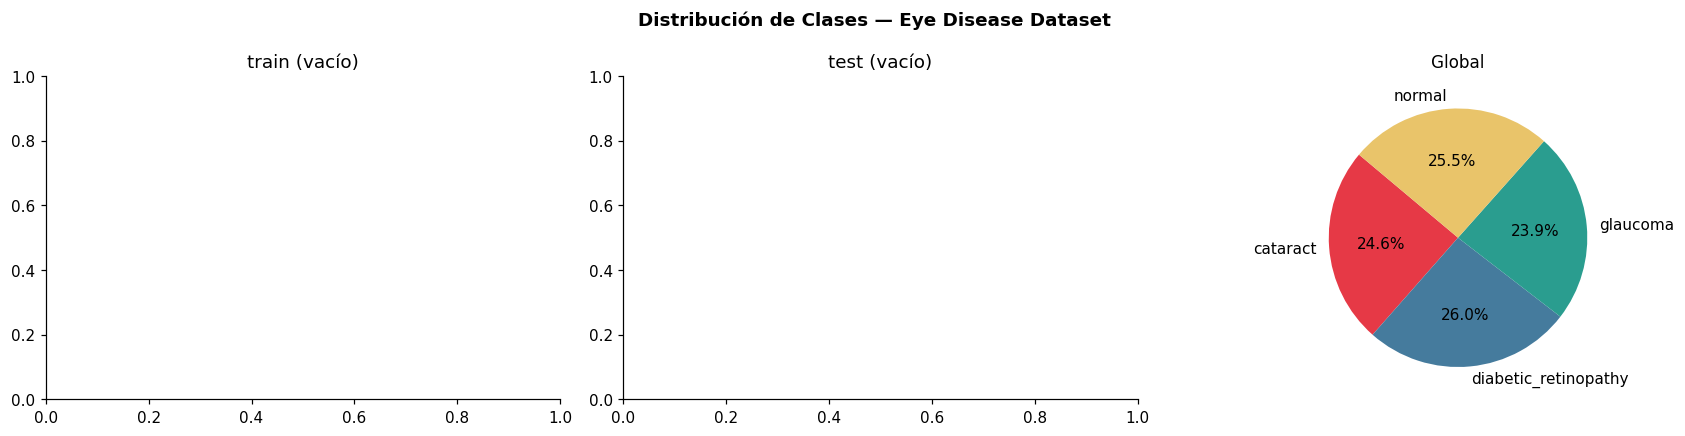


Conteos por split y clase:
class    cataract  diabetic_retinopathy  glaucoma  normal
split                                                    
unknown      1038                  1098      1007    1074


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Distribución de Clases — Eye Disease Dataset", fontweight="bold")

counts = readable.groupby(["split","class"]).size().reset_index(name="n")
global_c = readable.groupby("class").size().reset_index(name="n")

for ax, split in zip(axes[:2], SPLITS):
    sub = counts[counts["split"]==split]
    if sub.empty: ax.set_title(f"{split} (vacío)"); continue
    colors = [CLASS_PALETTE.get(c,"#888") for c in sub["class"]]
    bars = ax.bar(sub["class"], sub["n"], color=colors, edgecolor="white")
    ax.bar_label(bars, padding=3, fontsize=9)
    ax.set_title(f"Split: {split}", fontsize=11)
    ax.set_ylabel("Imágenes")
    ax.set_xticklabels(sub["class"], rotation=20, ha="right")
    if len(sub)>1 and sub["n"].min()>0:
        ratio = sub["n"].max()/sub["n"].min()
        ax.annotate(f"Ratio desbalance: {ratio:.2f}x",
                    xy=(0.97,0.96), xycoords="axes fraction",
                    ha="right", fontsize=8, color="dimgray")

colors = [CLASS_PALETTE.get(c,"#888") for c in global_c["class"]]
axes[2].pie(global_c["n"], labels=global_c["class"],
            autopct="%1.1f%%", colors=colors, startangle=140)
axes[2].set_title("Global", fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"01_class_distribution.png", bbox_inches="tight")
plt.show()

print("\nConteos por split y clase:")
print(readable.groupby(["split","class"]).size().unstack(fill_value=0).to_string())

### 2.3 · Distribución de resoluciones

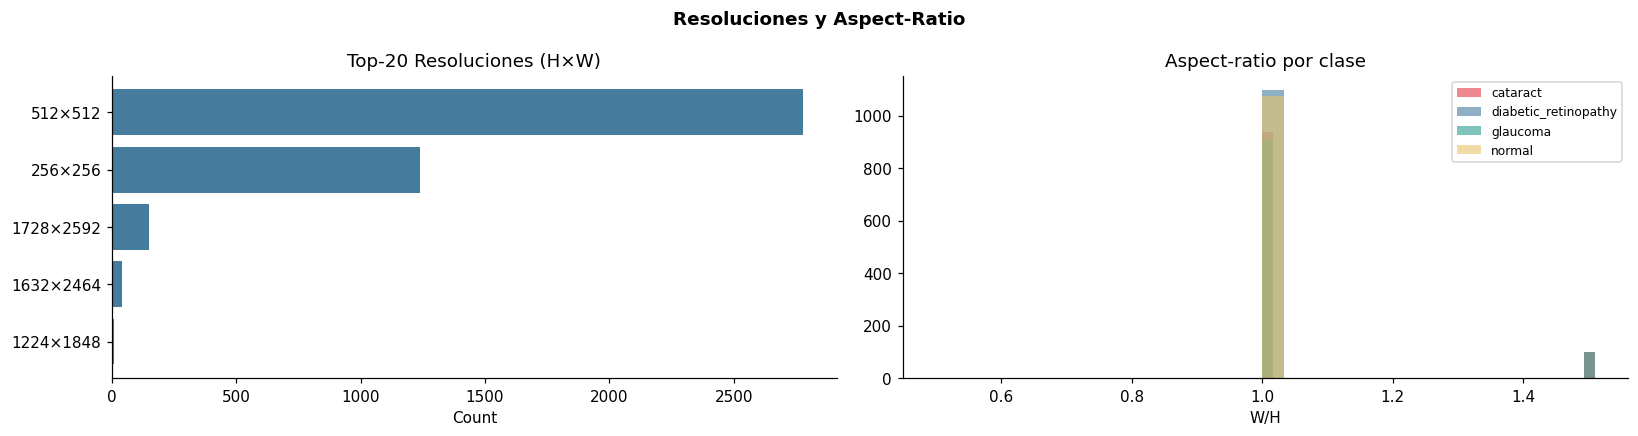

Resoluciones únicas: 5
Top-5: {'512×512': 2776, '256×256': 1240, '1728×2592': 150, '1632×2464': 41, '1224×1848': 10}


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
fig.suptitle("Resoluciones y Aspect-Ratio", fontweight="bold")

readable2 = readable.copy()
readable2["resolution"] = readable2["height"].astype(str)+"×"+readable2["width"].astype(str)
top_res = readable2["resolution"].value_counts().head(20)

axes[0].barh(top_res.index, top_res.values, color="#457B9D")
axes[0].invert_yaxis()
axes[0].set_title("Top-20 Resoluciones (H×W)")
axes[0].set_xlabel("Count")

for cls in CLASSES:
    sub = readable2[readable2["class"]==cls]["aspect_ratio"]
    if not sub.empty:
        axes[1].hist(sub, bins=30, alpha=0.6, label=cls,
                     color=CLASS_PALETTE.get(cls,"#888"))
axes[1].set_title("Aspect-ratio por clase")
axes[1].set_xlabel("W/H")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR/"02_resolution_distribution.png", bbox_inches="tight")
plt.show()

print(f"Resoluciones únicas: {readable2['resolution'].nunique()}")
print("Top-5:", top_res.head().to_dict())

### 2.4 · Métricas de calidad

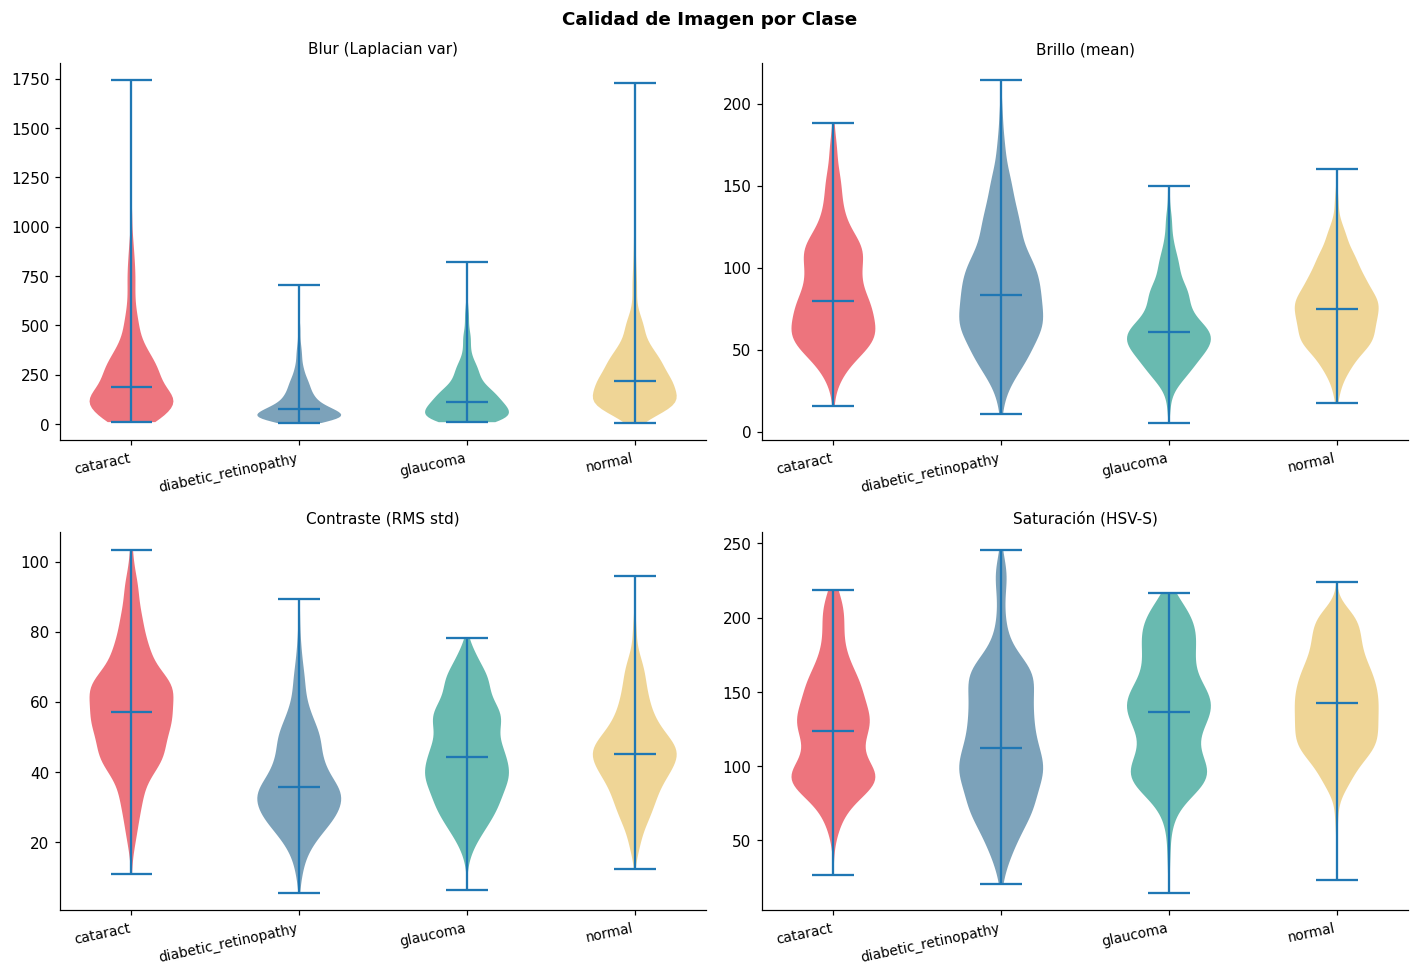

In [11]:
metrics = ["blur_laplacian","brightness_mean","contrast_rms","saturation_mean"]
titles  = ["Blur (Laplacian var)","Brillo (mean)","Contraste (RMS std)","Saturación (HSV-S)"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Calidad de Imagen por Clase", fontweight="bold")

for ax, metric, title in zip(axes.flat, metrics, titles):
    data = [readable[readable["class"]==c][metric].dropna().values for c in CLASSES]
    data = [d for d in data if len(d)>0]
    if not data: continue
    parts = ax.violinplot(data, positions=range(len(CLASSES)),
                          showmedians=True, showextrema=True)
    for i, pc in enumerate(parts["bodies"]):
        pc.set_facecolor(list(CLASS_PALETTE.values())[i%4])
        pc.set_alpha(0.7)
    ax.set_xticks(range(len(CLASSES)))
    ax.set_xticklabels(CLASSES, rotation=12, ha="right", fontsize=9)
    ax.set_title(title, fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR/"03_quality_metrics.png", bbox_inches="tight")
plt.show()

### 2.5 · Estadísticas RGB y flags de calidad

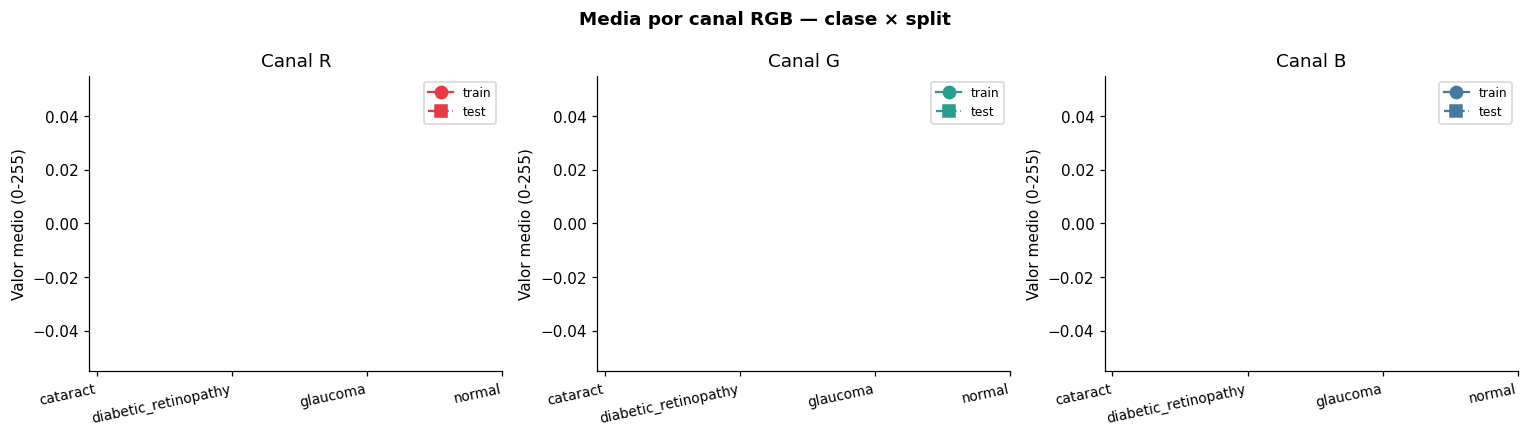


Flags de calidad:
                 count    pct
is_blurry         1578  37.42
is_dark            307   7.28
is_overexposed       0   0.00
is_low_contrast    673  15.96
quality_flag      1723  40.86


In [12]:
# RGB por canal y split
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Media por canal RGB — clase × split", fontweight="bold")

for ax, ch, color in zip(axes, ["r","g","b"],
                         ["#E63946","#2A9D8F","#457B9D"]):
    summary = readable.groupby(["class","split"])[f"{ch}_mean"].mean().reset_index()
    for split, marker in zip(SPLITS, ["o","s"]):
        sub = summary[summary["split"]==split]
        ax.plot(sub["class"], sub[f"{ch}_mean"], marker=marker, label=split,
                color=color, linestyle="--" if split=="test" else "-",
                linewidth=1.5, markersize=8)
    ax.set_title(f"Canal {ch.upper()}")
    ax.set_ylabel("Valor medio (0-255)")
    ax.set_xticks(range(len(CLASSES)))
    ax.set_xticklabels(CLASSES, rotation=12, ha="right", fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR/"04_rgb_stats.png", bbox_inches="tight")
plt.show()

# Resumen flags
flag_cols = ["is_blurry","is_dark","is_overexposed","is_low_contrast","quality_flag"]
flag_summary = readable[flag_cols].sum().rename("count").to_frame()
flag_summary["pct"] = (flag_summary["count"]/len(readable)*100).round(2)
print("\nFlags de calidad:")
print(flag_summary.to_string())

---
## 🔍 3 · Detección de Duplicados y Data Leakage

**Capa 1:** MD5 → duplicados exactos byte a byte  
**Capa 2:** pHash DCT-8×8 + Union-Find → near-duplicates visuales  
**Capa 3:** Análisis de leakage → mismo ojo en train Y test

In [13]:
def md5_hash(path: Path) -> str:
    h = hashlib.md5()
    with open(path,"rb") as f:
        for chunk in iter(lambda: f.read(65536), b""):
            h.update(chunk)
    return h.hexdigest()

def phash(path: Path, hash_size: int = 8):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    img_r = cv2.resize(img, (hash_size*4, hash_size*4),
                       interpolation=cv2.INTER_AREA).astype(np.float32)
    dct   = cv2.dct(img_r)
    dct_ll = dct[:hash_size, :hash_size]
    return (dct_ll > np.median(dct_ll)).flatten()

print("Funciones de hashing definidas ✓")

Funciones de hashing definidas ✓


In [14]:
# ── Escaneo y hashing ─────────────
hash_records = []
for p in tqdm(all_imgs, desc="MD5 + pHash"):
    split = next((s for s in SPLITS if f"/{s}/" in str(p) or f"\\{s}\\" in str(p)), "unknown")
    ph = phash(p)
    hash_records.append({
        "path": str(p), "split": split, "class": p.parent.name,
        "filename": p.name, "md5": md5_hash(p),
        "phash": ph.tolist() if ph is not None else None,
        "phash_ok": ph is not None,
    })

hash_df = pd.DataFrame(hash_records)
hash_df.to_csv(OUTPUT_DIR/"hash_index.csv", index=False)
print(f"✓ {len(hash_df)} imágenes indexadas")

MD5 + pHash:   0%|          | 0/4217 [00:00<?, ?it/s]

✓ 4217 imágenes indexadas


In [15]:
# ── Duplicados exactos (MD5) ──────────────────────────────────────────────────
exact_dups = hash_df[hash_df.duplicated("md5", keep=False)].sort_values("md5")
print(f"Duplicados exactos: {len(exact_dups)} imágenes en {exact_dups['md5'].nunique()} grupos")
if not exact_dups.empty:
    exact_dups.to_csv(OUTPUT_DIR/"exact_duplicates.csv", index=False)
    display(exact_dups[["path","split","class","md5"]].head(10))

Duplicados exactos: 4 imágenes en 2 grupos


,path,split,class,md5
1824,dataset/dataset/cataract/625_left.jpg,unknown,cataract,06f4c9b0835adcdddc48252f45f6480e
3881,dataset/dataset/glaucoma/625_left.jpg,unknown,glaucoma,06f4c9b0835adcdddc48252f45f6480e
1990,dataset/dataset/cataract/1415_right.jpg,unknown,cataract,e2d70a8954bcdd55ef63989a9a5b84c3
4051,dataset/dataset/glaucoma/1415_right.jpg,unknown,glaucoma,e2d70a8954bcdd55ef63989a9a5b84c3


In [16]:
# ── Union-Find ────────────────────────────────────────────────────────────────
class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n)); self.rank = [0]*n
    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]; x = self.parent[x]
        return x
    def union(self, x, y):
        rx, ry = self.find(x), self.find(y)
        if rx == ry: return
        if self.rank[rx] < self.rank[ry]: rx, ry = ry, rx
        self.parent[ry] = rx
        if self.rank[rx] == self.rank[ry]: self.rank[rx] += 1

# ── Near-dup clustering ───────────────────────────────────────────────────────
HAMMING_THRESH = 10   # <-- ajusta (0-64). 10/64 ≈ 15% de bits diferentes

valid = hash_df[hash_df["phash_ok"]].copy().reset_index(drop=True)
hashes = np.array(valid["phash"].tolist(), dtype=bool)
n  = len(hashes)
uf = UnionFind(n)
print(f"Calculando {n*(n-1)//2:,} distancias Hamming (thresh={HAMMING_THRESH})…")

BATCH = 500
for i in range(0, n, BATCH):
    chunk = hashes[i:i+BATCH]
    for j in range(i, n, BATCH):
        other = hashes[j:j+BATCH]
        dists = np.sum(chunk[:,None,:] != other[None,:,:], axis=2)
        rows, cols = np.where(dists <= HAMMING_THRESH)
        for r, c in zip(rows, cols):
            gi, gj = i+r, j+c
            if gi != gj: uf.union(gi, gj)

valid["cluster_id"] = [uf.find(i) for i in range(n)]
cmap = {old: new for new, old in enumerate(sorted(valid["cluster_id"].unique()))}
valid["cluster_id"] = valid["cluster_id"].map(cmap)

hash_df = hash_df.merge(valid[["path","cluster_id"]], on="path", how="left")
hash_df["cluster_id"] = hash_df["cluster_id"].fillna(-1).astype(int)
hash_df.to_csv(OUTPUT_DIR/"clustered_index.csv", index=False)

sizes = valid.groupby("cluster_id").size()
print(f"Clusters totales: {sizes.nunique()}")
print(f"Grupos con near-dups (>1 img): {(sizes>1).sum()}")
print(f"Imágenes en grupos near-dup: {sizes[sizes>1].sum()}")

Calculando 8,889,436 distancias Hamming (thresh=10)…
Clusters totales: 8
Grupos con near-dups (>1 img): 40
Imágenes en grupos near-dup: 3821


In [17]:
# ── Detección de leakage ──────────────────────────────────────────────────────
clustered = hash_df[hash_df["cluster_id"] >= 0]
cluster_splits = clustered.groupby("cluster_id")["split"].apply(set)
leaking_ids    = cluster_splits[cluster_splits.apply(
    lambda s: "train" in s and "test" in s)].index.tolist()
leaking_rows   = clustered[clustered["cluster_id"].isin(leaking_ids)]

print("=" * 55)
print(f"  LEAKAGE REPORT")
print("=" * 55)
print(f"  Clusters con leakage : {len(leaking_ids)}")
print(f"  Imágenes afectadas   : {len(leaking_rows)}")

if leaking_rows.empty:
    print("  ✓  Sin leakage train/test detectado")
else:
    severity = "CRÍTICO" if len(leaking_rows)>10 else "ADVERTENCIA"
    print(f"  ⚠  Severidad: {severity}")
    print("  Desglose por clase:")
    print(leaking_rows.groupby(["class","split"]).size().unstack(fill_value=0).to_string())
    leaking_rows.to_csv(OUTPUT_DIR/"leaking_images.csv", index=False)
    print("  → Guardado: leaking_images.csv")
print("=" * 55)

  LEAKAGE REPORT
  Clusters con leakage : 0
  Imágenes afectadas   : 0
  ✓  Sin leakage train/test detectado


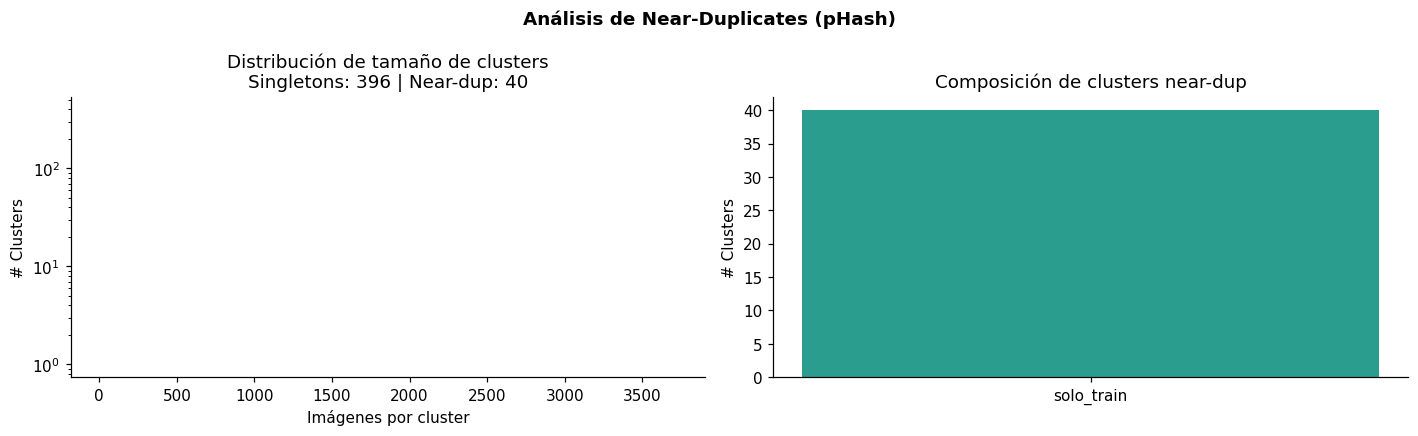

In [18]:
# ── Visualización de clusters ─────────────────────────────────────────────────
sizes = valid.groupby("cluster_id").size()
singleton = (sizes==1).sum(); near_dup = (sizes>1).sum()

multi = clustered[clustered["cluster_id"].isin(sizes[sizes>1].index)]
if not multi.empty:
    comp = multi.groupby(["cluster_id","split"]).size().unstack(fill_value=0)
    comp_type = comp.apply(
        lambda r: ("LEAKAGE" if (r.get("train",0)>0 and r.get("test",0)>0)
                   else "solo_train" if r.get("test",0)==0 else "solo_test"), axis=1
    ).value_counts()
else:
    comp_type = pd.Series(dtype=int)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Análisis de Near-Duplicates (pHash)", fontweight="bold")

size_counts = sizes.value_counts().sort_index()
axes[0].bar(size_counts.index, size_counts.values, color="#457B9D", edgecolor="white")
axes[0].set_xlabel("Imágenes por cluster")
axes[0].set_ylabel("# Clusters")
axes[0].set_title(f"Distribución de tamaño de clusters\nSingletons: {singleton} | Near-dup: {near_dup}")
if len(size_counts)>2: axes[0].set_yscale("log")

if not comp_type.empty:
    colors = {"solo_train":"#2A9D8F","solo_test":"#E9C46A","LEAKAGE":"#E63946"}
    axes[1].bar(comp_type.index, comp_type.values,
                color=[colors.get(k,"#888") for k in comp_type.index])
    axes[1].set_title("Composición de clusters near-dup")
    axes[1].set_ylabel("# Clusters")
else:
    axes[1].text(0.5, 0.5, "Sin near-duplicates", ha="center", va="center",
                 transform=axes[1].transAxes, fontsize=12)
    axes[1].set_title("Composición de clusters near-dup")

plt.tight_layout()
plt.savefig(OUTPUT_DIR/"05_cluster_analysis.png", bbox_inches="tight")
plt.show()

---
## 🔀 4 · Pipeline Reproducible

**Unidad de split: pseudo-paciente (cluster pHash), no imagen individual.**  
Ningún cluster cruza la frontera train/val/test.  
Genera `manifest.json` con SHA-256 de cada imagen → versioning sin DVC.

In [19]:
# ── Config del split ─────────────────────────────────────────────────────────
VAL_SIZE  = 0.15
TEST_SIZE = 0.15
SEED      = 42
IMG_SIZE  = 224
DATASET_NAME = "eye-diseases-classification-v1"

# ── Excluir imágenes con leakage ─────────────────────────────────────────────
leak_path = OUTPUT_DIR / "leaking_images.csv"
if leak_path.exists():
    leak_paths = set(pd.read_csv(leak_path)["path"].tolist())
    before = len(all_imgs)
    clean_imgs = [p for p in all_imgs if str(p) not in leak_paths]
    print(f"Excluidas {before - len(clean_imgs)} imágenes con leakage → {len(clean_imgs)} restantes")
else:
    clean_imgs = list(all_imgs)
    print("Sin leakage — usando todas las imágenes")

# ── Cargar dataset limpio ────────────────────────────────────────────────────
records = []
for p in clean_imgs:
    cls = p.parent.name
    if cls not in LABEL_MAP: continue
    records.append({"path": str(p), "class": cls, "label": LABEL_MAP[cls], "filename": p.name})

pipe_df = pd.DataFrame(records)
print(f"✓ {len(pipe_df)} imágenes válidas en {pipe_df['class'].nunique()} clases")

Sin leakage — usando todas las imágenes
✓ 4217 imágenes válidas en 4 clases


In [20]:
# ── Asignar grupos (pseudo-paciente) ─────────────────────────────────────────
cluster_csv = OUTPUT_DIR / "clustered_index.csv"
if cluster_csv.exists():
    clusters = pd.read_csv(cluster_csv, usecols=["path","cluster_id"])
    pipe_df  = pipe_df.merge(clusters, on="path", how="left")
    pipe_df["cluster_id"] = pipe_df["cluster_id"].fillna(-1).astype(int)
    next_id = pipe_df["cluster_id"].max() + 1
    mask    = pipe_df["cluster_id"] == -1
    pipe_df.loc[mask, "cluster_id"] = range(next_id, next_id + mask.sum())
    pipe_df["group_id"] = pipe_df["cluster_id"]
    print(f"✓ {pipe_df['group_id'].nunique()} grupos pseudo-paciente")
else:
    pipe_df["group_id"] = range(len(pipe_df))
    print("Sin clusters → cada imagen es su propio grupo (conservador)")

✓ 436 grupos pseudo-paciente


In [21]:
# ── Split estratificado por grupo ─────────────────────────────────────────────
group_df = (pipe_df.groupby("group_id")
            .agg(class_=("class", lambda x: x.mode()[0]),
                 label_=("label", lambda x: int(x.mode()[0])),
                 n_images=("path","count"))
            .reset_index())

n_test_fold = max(2, round(1.0 / TEST_SIZE))
sgkf = StratifiedGroupKFold(n_splits=n_test_fold, shuffle=True, random_state=SEED)
train_val_idx, test_idx = next(
    sgkf.split(group_df, group_df["label_"], groups=group_df["group_id"]))
test_gids    = set(group_df.iloc[test_idx]["group_id"])
train_val_df = group_df.iloc[train_val_idx]

val_frac  = VAL_SIZE / (1.0 - TEST_SIZE)
n_val_fold = max(2, round(1.0 / val_frac))
sgkf2 = StratifiedGroupKFold(n_splits=n_val_fold, shuffle=True, random_state=SEED+1)
train_idx, val_idx = next(
    sgkf2.split(train_val_df, train_val_df["label_"], groups=train_val_df["group_id"]))
val_gids   = set(train_val_df.iloc[val_idx]["group_id"])
train_gids = set(train_val_df.iloc[train_idx]["group_id"])

def assign_split(gid):
    if gid in test_gids:  return "test"
    if gid in val_gids:   return "val"
    return "train"

pipe_df["split"] = pipe_df["group_id"].apply(assign_split)

# Verificar que ningún grupo cruza splits
cross = pipe_df.groupby("group_id")["split"].nunique()
assert (cross > 1).sum() == 0, "BUG: grupo cruzando splits!"
print("✓ Ningún grupo cruza la frontera de splits")

counts = pipe_df.groupby(["split","class"]).size().unstack(fill_value=0)
print("\nDistribución final:")
print(counts.to_string())
pipe_df[["path","class","label","split","group_id"]].to_csv(
    OUTPUT_DIR/"split_index.csv", index=False)
print("\n✓ Guardado: split_index.csv")

✓ Ningún grupo cruza la frontera de splits

Distribución final:
class  cataract  diabetic_retinopathy  glaucoma  normal
split                                                  
test         16                    26        13      15
train      1002                  1048       980    1041
val          20                    24        14      18

✓ Guardado: split_index.csv


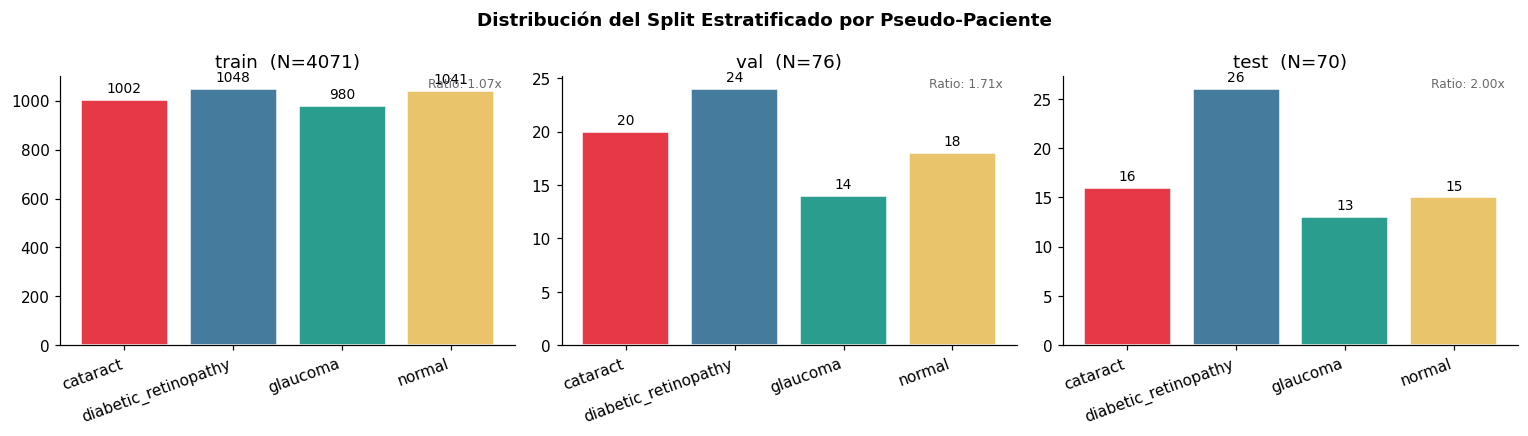

In [22]:
# ── Visualizar el split ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Distribución del Split Estratificado por Pseudo-Paciente", fontweight="bold")

for ax, split in zip(axes, ["train","val","test"]):
    sub = pipe_df[pipe_df["split"]==split].groupby("class").size()
    colors = [CLASS_PALETTE.get(c,"#888") for c in sub.index]
    bars = ax.bar(sub.index, sub.values, color=colors, edgecolor="white")
    ax.bar_label(bars, padding=3, fontsize=9)
    ax.set_title(f"{split}  (N={sub.sum()})")
    ax.set_xticklabels(sub.index, rotation=20, ha="right")
    if sub.min()>0:
        ax.annotate(f"Ratio: {sub.max()/sub.min():.2f}x",
                    xy=(0.97,0.96), xycoords="axes fraction",
                    ha="right", fontsize=8, color="dimgray")

plt.tight_layout()
plt.savefig(OUTPUT_DIR/"06_split_distribution.png", bbox_inches="tight")
plt.show()

In [23]:
# ── Augmentation config documentada ─────────────────────────────────────────
AUGMENTATION_CONFIG = {
    "seed": SEED,
    "img_size": IMG_SIZE,
    "train": [
        {"name": "HorizontalFlip",    "p": 0.5,
         "rationale": "Seguro — la retina no tiene quiralidad diagnóstica"},
        {"name": "VerticalFlip",      "p": 0.5},
        {"name": "Rotate",            "limit": 15, "p": 1.0},
        {"name": "RandomResizedCrop", "scale": [0.85,1.0], "p": 1.0},
        {"name": "ColorJitter",       "brightness": 0.2, "contrast": 0.2,
         "saturation": 0.15, "hue": 0.05, "p": 0.8,
         "rationale": "Simula variación de cámara; hue limitado — el color retinal es diagnóstico"},
        {"name": "GaussianBlur",      "sigma": [0.1,1.0], "p": 0.2},
    ],
    "val":  [{"name": "Resize", "size": IMG_SIZE}, {"name": "CenterCrop", "size": IMG_SIZE}],
    "test": [{"name": "Resize", "size": IMG_SIZE}, {"name": "CenterCrop", "size": IMG_SIZE}],
    "normalisation": {"mean": [0.485,0.456,0.406], "std": [0.229,0.224,0.225],
                      "note": "ImageNet — reemplazar con stats del dataset si entrenas desde cero"},
    "EXCLUIDO": {
        "RandomErasing": "Enmascara lesiones clínicamente relevantes",
        "CutMix/MixUp":  "Crea imágenes retinales físicamente imposibles",
        "elastic_deform": "Distorsiona tortuosidad vascular (cue diagnóstico en DR y glaucoma)",
        "aggressive_hue": "Hemorragias DR y palidez disco (glaucoma) son color-dependientes",
    }
}

with open(OUTPUT_DIR/"augmentation_config.json","w") as f:
    json.dump(AUGMENTATION_CONFIG, f, indent=2)
print("✓ augmentation_config.json guardado")
print("\nTransforms de train:")
for t in AUGMENTATION_CONFIG["train"]:
    rat = f"  # {t['rationale']}" if "rationale" in t else ""
    print(f"  {t['name']:<22} p={t.get('p','—')}{rat}")

✓ augmentation_config.json guardado

Transforms de train:
  HorizontalFlip         p=0.5  # Seguro — la retina no tiene quiralidad diagnóstica
  VerticalFlip           p=0.5
  Rotate                 p=1.0
  RandomResizedCrop      p=1.0
  ColorJitter            p=0.8  # Simula variación de cámara; hue limitado — el color retinal es diagnóstico
  GaussianBlur           p=0.2


In [24]:
# ── Data manifest con SHA-256 (versioning sin DVC) ──────────────────────────
def sha256(path: Path) -> str:
    h = hashlib.sha256()
    with open(path,"rb") as f:
        for chunk in iter(lambda: f.read(65536), b""):
            h.update(chunk)
    return h.hexdigest()

print("Calculando SHA-256 para manifest…")
pipe_df2 = pipe_df.copy()
pipe_df2["sha256"] = [sha256(Path(p)) for p in tqdm(pipe_df2["path"], desc="SHA-256")]

split_counts = pipe_df2.groupby(["split","class"]).size().unstack(fill_value=0).to_dict()
manifest = {
    "dataset": DATASET_NAME,
    "created_at": pd.Timestamp.utcnow().isoformat(),
    "seed": SEED, "val_size": VAL_SIZE, "test_size": TEST_SIZE,
    "n_images": len(pipe_df2),
    "split_counts": split_counts,
    "augmentation_config": AUGMENTATION_CONFIG,
    "images": pipe_df2[["path","class","label","split","group_id","sha256"]].to_dict("records"),
}
with open(OUTPUT_DIR/"manifest.json","w") as f:
    json.dump(manifest, f, indent=2)
print(f"✓ manifest.json guardado ({len(pipe_df2)} entradas)")
print("  → Haz commit de manifest.json en Git para versionar el dataset exacto")

Calculando SHA-256 para manifest…


SHA-256:   0%|          | 0/4217 [00:00<?, ?it/s]

✓ manifest.json guardado (4217 entradas)
  → Haz commit de manifest.json en Git para versionar el dataset exacto


---
##5 · Detección de Sesgo de Fuente (Source Bias)

El dataset mezcla IDRiD, HRF, ODIR, Messidor, Kaggle DR con distintas cámaras y calidades.  
Un modelo puede aprender *"esta resolución → esta clase"* en lugar de *"estas lesiones → esta clase"*.

**Tests:** χ² (independencia fuente×clase) · KS-test (distribución de métricas) · Bhattacharyya (color)

In [25]:
# Firmas de resolución de datasets públicos conocidos
KNOWN_SOURCES = {
    "IDRiD":    {"res": [(2848,4288),(2848,4290)]},
    "HRF":      {"res": [(3504,4752)]},
    "ODIR":     {"res": [(1444,1444),(2000,2000)]},
    "Messidor": {"res": [(1440,960),(1500,1000),(2240,1488)]},
    "REFUGE":   {"res": [(2056,2124)]},
    "RIMONEr3": {"res": [(2048,2144)]},
}

def extract_source_features(path: Path) -> dict:
    rec = {"path": str(path), "readable": False,
           "split": next((s for s in SPLITS if f"/{s}/" in str(path)
                          or f"\\{s}\\" in str(path)), "unknown"),
           "class": path.parent.name}
    img = cv2.imread(str(path))
    if img is None: return rec
    rec["readable"] = True
    h, w = img.shape[:2]
    rec["height"] = h; rec["width"] = w; rec["aspect"] = round(w/h,4)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
    r,g,b   = img_rgb[:,:,0], img_rgb[:,:,1], img_rgb[:,:,2]
    gray    = img_rgb.mean(axis=2)
    rec["black_fraction"]  = float((gray<10).mean())
    total = r+g+b+1e-9
    rec["green_dominance"] = float((g/total).mean())
    rec["rB_ratio"]        = float((r.mean()+1e-9)/(b.mean()+1e-9))
    for ch_arr, ch_name in [(r,"r"),(g,"g"),(b,"b")]:
        hist,_ = np.histogram(ch_arr, bins=64, range=(0,256))
        hist   = hist/(hist.sum()+1e-9)
        rec[f"entropy_{ch_name}"] = float(-np.sum(hist*np.log2(hist+1e-12)))
    rec["sharpness"] = float(cv2.Laplacian(g.astype(np.uint8), cv2.CV_64F).var())
    return rec

print("Extrayendo features de fuente…")
bias_records = [extract_source_features(p) for p in tqdm(all_imgs, desc="Source scan")]
bias_df = pd.DataFrame(bias_records)
bias_readable = bias_df[bias_df["readable"]].copy()
print(f"✓ {len(bias_readable)} imágenes válidas")

Extrayendo features de fuente…


Source scan:   0%|          | 0/4217 [00:00<?, ?it/s]

✓ 4217 imágenes válidas


In [26]:
# ── Matching por resolución conocida ─────────────────────────────────────────
bias_readable["known_source"] = "unknown"
for src, meta in KNOWN_SOURCES.items():
    for h,w in meta["res"]:
        mask = (bias_readable["height"]==h) & (bias_readable["width"]==w)
        bias_readable.loc[mask,"known_source"] = src

matched = (bias_readable["known_source"]!="unknown").sum()
print(f"Imágenes con fuente conocida (por resolución): {matched}/{len(bias_readable)}")
print(bias_readable["known_source"].value_counts().to_string())

Imágenes con fuente conocida (por resolución): 0/4217
known_source
unknown    4217


In [27]:
# ── K-Means clustering de fuente ─────────────────────────────────────────────
N_SOURCE_CLUSTERS = 6

CLUSTER_FEATS = ["height","width","aspect","black_fraction",
                 "green_dominance","rB_ratio","entropy_r","entropy_g","entropy_b","sharpness"]
feat_cols = [c for c in CLUSTER_FEATS if c in bias_readable.columns]
X = bias_readable[feat_cols].fillna(0).values

scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

km = KMeans(n_clusters=N_SOURCE_CLUSTERS, random_state=42, n_init=10)
bias_readable["source_cluster"] = km.fit_predict(X_sc)

print(f"✓ {N_SOURCE_CLUSTERS} clusters de fuente descubiertos")
print(bias_readable.groupby("source_cluster")["class"].value_counts().unstack(fill_value=0).to_string())

✓ 6 clusters de fuente descubiertos
class           cataract  diabetic_retinopathy  glaucoma  normal
source_cluster                                                  
0                    100                     0       101       0
1                    251                   462       437     576
2                    315                    78       125     300
3                    176                    26       161       8
4                     46                    20        49      78
5                    150                   512       134     112


In [28]:
# ── Tests estadísticos ────────────────────────────────────────────────────────
# 1. χ² de independencia fuente × clase
ct = pd.crosstab(bias_readable["source_cluster"], bias_readable["class"])
chi2_stat, p_chi2, dof, _ = stats.chi2_contingency(ct)
cramers_v = float(np.sqrt(chi2_stat/(ct.sum().sum()*(min(ct.shape)-1))))

print("χ² Independencia fuente × clase:")
print(f"  χ² = {chi2_stat:.2f}  |  p = {p_chi2:.4f}  |  Cramér's V = {cramers_v:.3f}")
bias_label = ("ninguno" if cramers_v<0.1 else "débil" if cramers_v<0.3
              else "moderado" if cramers_v<0.5 else "FUERTE")
sig = p_chi2 < 0.05
print(f"  → {'⚠  SESGO DETECTADO' if sig else '✓  Sin sesgo significativo'}  ({bias_label})")

# 2. KS-tests por métrica
print("\nKS-tests por métrica (cluster 0 vs resto):")
ks_metrics = [c for c in ["sharpness","black_fraction","green_dominance",
                            "entropy_g","rB_ratio"] if c in bias_readable.columns]
ks_results = []
c0    = bias_readable["source_cluster"].min()
rest  = bias_readable[bias_readable["source_cluster"]!=c0]
c0_df = bias_readable[bias_readable["source_cluster"]==c0]
for metric in ks_metrics:
    a = c0_df[metric].dropna().values
    b = rest[metric].dropna().values
    if len(a)==0 or len(b)==0: continue
    ks, p = stats.ks_2samp(a, b)
    concern = "ALTO" if (p<0.05 and ks>0.2) else "MEDIO" if p<0.05 else "BAJO"
    ks_results.append({"metric":metric,"KS":round(ks,3),"p":round(p,4),"concern":concern})
    print(f"  {metric:<22}: KS={ks:.3f}  p={p:.4f}  [{concern}]")

χ² Independencia fuente × clase:
  χ² = 1286.71  |  p = 0.0000  |  Cramér's V = 0.319
  → ⚠  SESGO DETECTADO  (moderado)

KS-tests por métrica (cluster 0 vs resto):
  sharpness             : KS=0.925  p=0.0000  [ALTO]
  black_fraction        : KS=0.938  p=0.0000  [ALTO]
  green_dominance       : KS=0.791  p=0.0000  [ALTO]
  entropy_g             : KS=0.841  p=0.0000  [ALTO]
  rB_ratio              : KS=0.252  p=0.0000  [ALTO]


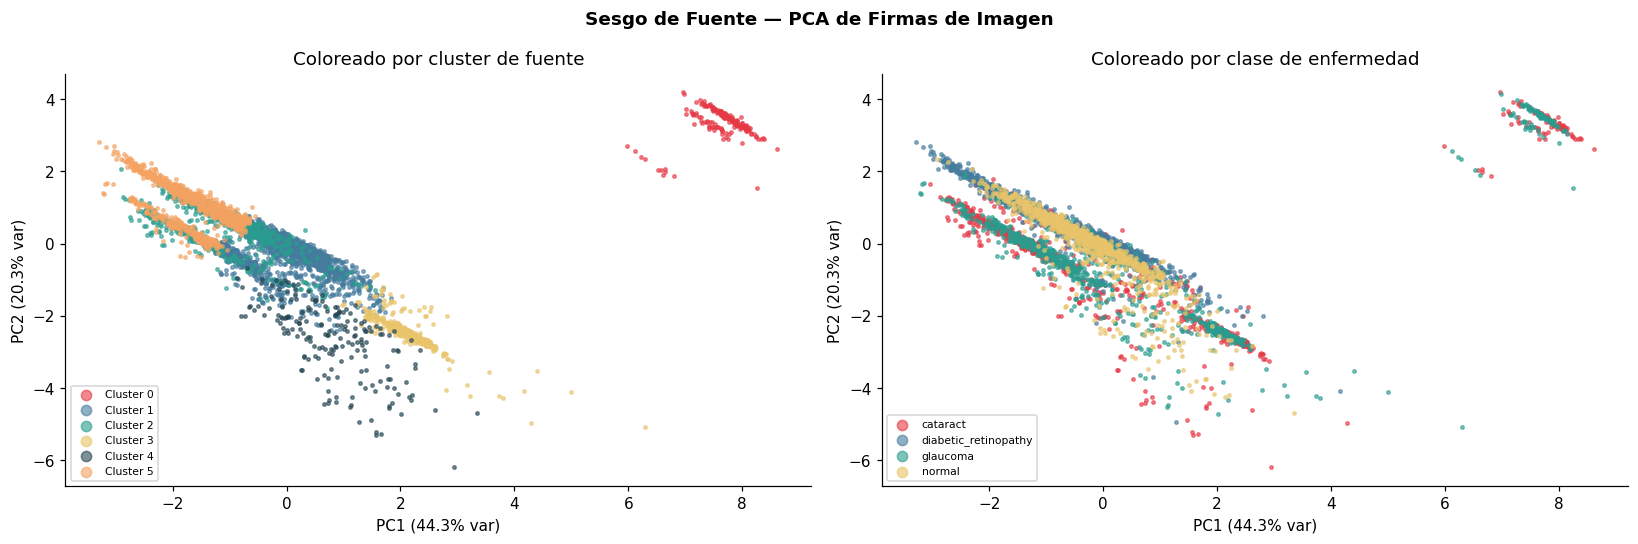


Interpretación:
  Si los colores de AMBOS plots se solapan → no hay correlación fuente-clase
  Si los clusters de fuente (izq) se alinean con clases (der) → SESGO


In [29]:
# ── PCA de firmas de fuente ───────────────────────────────────────────────────
pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_sc)
var  = pca.explained_variance_ratio_

PALETTE = ["#E63946","#457B9D","#2A9D8F","#E9C46A","#264653","#F4A261"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Sesgo de Fuente — PCA de Firmas de Imagen", fontweight="bold")

clusters = sorted(bias_readable["source_cluster"].unique())
for i, c in enumerate(clusters):
    mask = bias_readable["source_cluster"]==c
    axes[0].scatter(X_2d[mask,0], X_2d[mask,1],
                    c=PALETTE[i%len(PALETTE)], s=5, alpha=0.6, label=f"Cluster {c}")
axes[0].set_xlabel(f"PC1 ({var[0]:.1%} var)")
axes[0].set_ylabel(f"PC2 ({var[1]:.1%} var)")
axes[0].set_title("Coloreado por cluster de fuente")
axes[0].legend(fontsize=7, markerscale=3)

class_colors = {"cataract":"#E63946","diabetic_retinopathy":"#457B9D",
                "glaucoma":"#2A9D8F","normal":"#E9C46A"}
for cls, color in class_colors.items():
    mask = bias_readable["class"]==cls
    if mask.any():
        axes[1].scatter(X_2d[mask,0], X_2d[mask,1],
                        c=color, s=5, alpha=0.6, label=cls)
axes[1].set_xlabel(f"PC1 ({var[0]:.1%} var)")
axes[1].set_ylabel(f"PC2 ({var[1]:.1%} var)")
axes[1].set_title("Coloreado por clase de enfermedad")
axes[1].legend(fontsize=7, markerscale=3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR/"07_source_pca.png", bbox_inches="tight")
plt.show()

print("\nInterpretación:")
print("  Si los colores de AMBOS plots se solapan → no hay correlación fuente-clase")
print("  Si los clusters de fuente (izq) se alinean con clases (der) → SESGO")

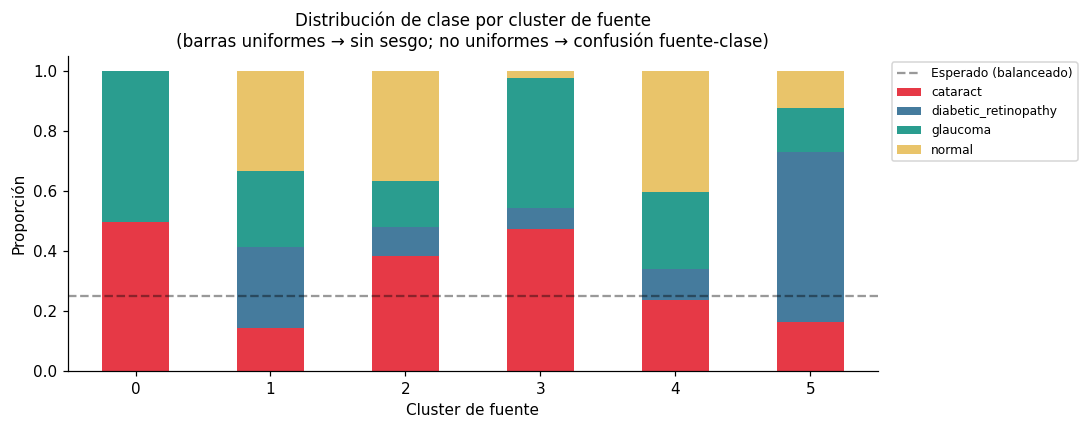

In [30]:
# ── Distribución de clase por fuente ─────────────────────────────────────────
ct_norm = pd.crosstab(bias_readable["source_cluster"],
                       bias_readable["class"], normalize="index")

fig, ax = plt.subplots(figsize=(10, 4))
ct_norm.plot(kind="bar", ax=ax, stacked=True,
             color=["#E63946","#457B9D","#2A9D8F","#E9C46A"])
ax.set_title("Distribución de clase por cluster de fuente\n"
             "(barras uniformes → sin sesgo; no uniformes → confusión fuente-clase)",
             fontsize=11)
ax.set_ylabel("Proporción")
ax.set_xlabel("Cluster de fuente")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.axhline(0.25, color="black", linestyle="--", alpha=0.4, label="Esperado (balanceado)")
ax.legend(fontsize=8, bbox_to_anchor=(1.01,1), loc="upper left")
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"08_class_per_source.png", bbox_inches="tight")
plt.show()

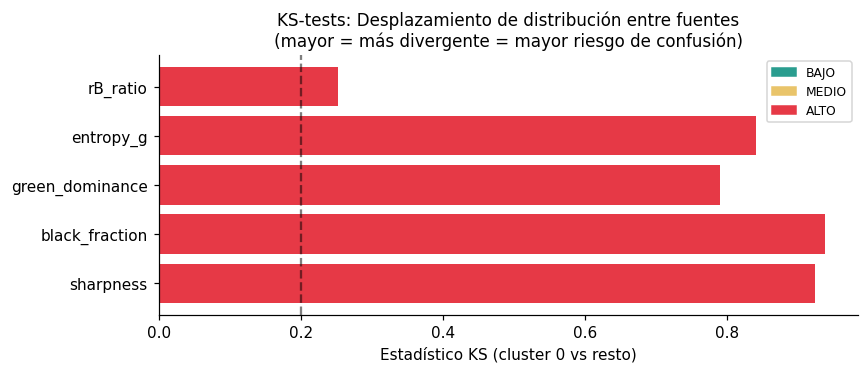

In [31]:
# ── KS heatmap ───────────────────────────────────────────────────────────────
if ks_results:
    df_ks = pd.DataFrame(ks_results).set_index("metric")
    fig, ax = plt.subplots(figsize=(8, max(3, len(df_ks)*0.7)))
    color_map = {"BAJO":"#2A9D8F","MEDIO":"#E9C46A","ALTO":"#E63946"}
    colors = [color_map[c] for c in df_ks["concern"]]
    ax.barh(df_ks.index, df_ks["KS"], color=colors)
    ax.axvline(0.2, color="black", linestyle="--", alpha=0.5)
    ax.set_xlabel("Estadístico KS (cluster 0 vs resto)")
    ax.set_title("KS-tests: Desplazamiento de distribución entre fuentes\n"
                 "(mayor = más divergente = mayor riesgo de confusión)", fontsize=11)
    handles = [mpatches.Patch(color=c, label=k) for k,c in color_map.items()]
    ax.legend(handles=handles, fontsize=8)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR/"09_ks_tests.png", bbox_inches="tight")
    plt.show()

---
## ✅ 6 · Resumen Final y Próximos Pasos

In [32]:
print("=" * 65)
print("  RESUMEN DEL PIPELINE")
print("=" * 65)
print(f"  Dataset          : {DATASET_NAME}")
print(f"  Imágenes totales : {len(all_imgs)}")

# EDA
print(f"\n  [EDA]")
print(f"  Corruptas        : {len(eda_df)-len(readable)}")
q_n = readable["quality_flag"].sum() if "quality_flag" in readable.columns else "—"
print(f"  Flags de calidad : {q_n}  ({100*q_n/len(readable):.1f}%)" if isinstance(q_n,int) else f"  Flags de calidad : —")
print(f"  Resoluciones únicas: {(readable['height'].astype(str)+'x'+readable['width'].astype(str)).nunique()}")

# Dedup
print(f"\n  [DEDUP & LEAKAGE]")
print(f"  Duplicados exactos : {len(exact_dups)}")
print(f"  Hamming thresh     : {HAMMING_THRESH}/64")
print(f"  Leakage clusters   : {len(leaking_ids)}")
print(f"  Leakage imágenes   : {len(leaking_rows)}")

# Pipeline
print(f"\n  [SPLIT — seed={SEED}]")
for s in ["train","val","test"]:
    n = (pipe_df["split"]==s).sum() if "split" in pipe_df.columns else "—"
    print(f"  {s:<6}: {n} imgs | {pipe_df[pipe_df['split']==s]['group_id'].nunique() if 'split' in pipe_df.columns else '—'} grupos")

# Bias
print(f"\n  [SESGO DE FUENTE]")
print(f"  Clusters fuente  : {N_SOURCE_CLUSTERS}")
print(f"  χ² p-value       : {p_chi2:.4f}  ({'⚠ sesgo' if sig else '✓ OK'})")
print(f"  Cramér's V       : {cramers_v:.3f}  ({bias_label})")

print(f"\n  Outputs guardados en: {OUTPUT_DIR.resolve()}/")
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f"    {f.name}")

print("=" * 65)
print()
print("  PRÓXIMOS PASOS:")
print("  1. Revisar quality_outliers en image_features.csv")
print("  2. Si leakage > 0: excluir leaking_images.csv antes de entrenar")
print("  3. Usar split_index.csv como índice de datos para DataLoader")
print("  4. Commitear manifest.json al repo para versionar el dataset")
if sig and cramers_v > 0.1:
    print("  5. ⚠  Sesgo detectado → considerar DANN/CORAL o estratificación por fuente")
else:
    print("  5. Monitorear métricas por cluster de fuente en evaluación")

  RESUMEN DEL PIPELINE
  Dataset          : eye-diseases-classification-v1
  Imágenes totales : 4217

  [EDA]
  Corruptas        : 0
  Flags de calidad : —
  Resoluciones únicas: 5

  [DEDUP & LEAKAGE]
  Duplicados exactos : 4
  Hamming thresh     : 10/64
  Leakage clusters   : 0
  Leakage imágenes   : 0

  [SPLIT — seed=42]
  train : 4071 imgs | 311 grupos
  val   : 76 imgs | 63 grupos
  test  : 70 imgs | 62 grupos

  [SESGO DE FUENTE]
  Clusters fuente  : 6
  χ² p-value       : 0.0000  (⚠ sesgo)
  Cramér's V       : 0.319  (moderado)

  Outputs guardados en: /content/results/
    01_class_distribution.png
    02_resolution_distribution.png
    03_quality_metrics.png
    04_rgb_stats.png
    05_cluster_analysis.png
    06_split_distribution.png
    07_source_pca.png
    08_class_per_source.png
    09_ks_tests.png
    augmentation_config.json
    clustered_index.csv
    exact_duplicates.csv
    hash_index.csv
    image_features.csv
    manifest.json
    split_index.csv

  PRÓXIMOS PASO